# Milestone 2
**Authors:** Omar Mohsen & Youssf Mostafa & Ahmed Abdallah | 
**Project:** End-to-End-Vision-Pipeline-from-Scratch

This notebook represents the final machine learning pipeline. It contains from-scratch mathematical implementations of **K-Nearest Neighbors (KNN)**, **Softmax Regression**, and a **Convolutional Neural Network (CNN)** using pure NumPy. Finally, we implement **MobileNetV2** (via PyTorch) as our advanced research architecture and compare all four models.

### Project Architecture
1. **Data & Visualization:** Loading MRMR features (1D) and raw image tensors (4D).
2. **KNN Baseline:** Pure NumPy distance calculation.
3. **Softmax Regression:** Custom Adam optimizer, Mini-Batch Gradient Descent, L2 Regularization, Early Stopping.
4. **Custom CNN:** Object-oriented Layer architectures (Conv2D, ReLU, MaxPool, Dense) with vectorized forward passes.
5. **MobileNetV2:** Transfer learning on a modern research architecture.
6. **Final Evaluation:** Confusion matrices, Precision, Recall, and Macro F1 scores.

In [11]:
# 1. Standard Imports & Setup
import os, json, time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# 2. PyTorch Imports (For MobileNetV2)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights

# 3. CUSTOM MODULE IMPORTS 
# (Note: Ensure your Python files are named accordingly without leading numbers, 
# e.g., knn_baseline.py, softmax_regression.py, cnn_network.py, optimizers.py)
from knn_baseline import KNNClassifier
from softmax_regression import SoftmaxRegression
from cnn_network import CustomCNN
from optimizers import Adam, SGD

# Setup visualization style
plt.style.use('dark_background')
sns.set_theme(style="darkgrid", rc={"axes.facecolor": "#1a1a2e", "figure.facecolor": "#0f1117", "text.color": "white"})

# Directories
DATA_DIR = r"../data"
FEAT_DIR = r"../features"
CLASS_NAMES = ["butterfly", "cat", "chicken", "cow", "dog", "elephant", "horse", "sheep", "spider", "squirrel"]

# Helper function for evaluation metrics (Phase 8)
def evaluate_metrics(y_true, y_pred, title):
    acc = np.sum(y_true == y_pred) / len(y_true)
    cm = np.zeros((10, 10), dtype=int)
    for t, p in zip(y_true, y_pred): cm[t, p] += 1
    
    TP = np.diag(cm)
    FP = np.sum(cm, axis=0) - TP
    FN = np.sum(cm, axis=1) - TP
    
    prec = np.divide(TP, TP + FP, out=np.zeros_like(TP, dtype=float), where=(TP+FP)!=0)
    rec  = np.divide(TP, TP + FN, out=np.zeros_like(TP, dtype=float), where=(TP+FN)!=0)
    f1   = np.divide(2 * prec * rec, prec + rec, out=np.zeros_like(prec), where=(prec+rec)!=0)
    
    macro_f1 = np.mean(f1)
    print(f"--- {title} ---")
    print(f"Accuracy: {acc*100:.2f}% | Macro F1: {macro_f1:.4f}\n")
    return acc, macro_f1, cm

## Section 1: Data Architecture & Visualization
Image classification requires different data structures depending on the algorithm's capability to understand spatial dimensions. Therefore, we maintain two parallel data streams:

1. **1D MRMR Features (100 dimensions):** High-dimensional raw images suffer from the *Curse of Dimensionality*, which severely degrades distance-based metrics. For our KNN and Softmax models, we load the 100 mathematically optimal features selected via Minimum Redundancy Maximum Relevance (MRMR) in Phase 3.
2. **4D Image Tensors ($N \times 128 \times 128 \times 3$):** Convolutional Neural Networks are explicitly designed to leverage spatial hierarchies (edges, textures, shapes). For our CNN and MobileNetV2, we feed the raw, normalized image tensors.

Loading MRMR Features...
Loading 4D Image Tensors...
MRMR Train Shape:  (12059, 100)
Image Train Shape: (12059, 128, 128, 3)


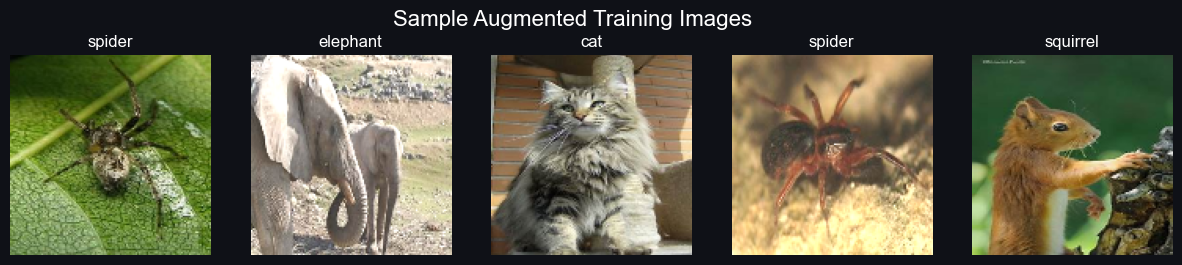

In [4]:
# Load 1D MRMR Features
print("Loading MRMR Features...")
X_train_mrmr = np.load(os.path.join(FEAT_DIR, "X_train_selected.npy"))
Y_train_1d   = np.load(os.path.join(FEAT_DIR, "Y_train.npy")).astype(int)
X_val_mrmr   = np.load(os.path.join(FEAT_DIR, "X_val_selected.npy"))
Y_val_1d     = np.load(os.path.join(FEAT_DIR, "Y_val.npy")).astype(int)
X_test_mrmr  = np.load(os.path.join(FEAT_DIR, "X_test_selected.npy"))
Y_test_1d    = np.load(os.path.join(FEAT_DIR, "Y_test.npy")).astype(int)

# Load 4D Image Tensors (Normalized to 0-1)
print("Loading 4D Image Tensors...")
X_train_img = np.load(os.path.join(DATA_DIR, "X_train_augmented.npy")).astype(np.float32) / 255.0
X_val_img   = np.load(os.path.join(DATA_DIR, "X_val.npy")).astype(np.float32) / 255.0
X_test_img  = np.load(os.path.join(DATA_DIR, "X_test.npy")).astype(np.float32) / 255.0

print(f"MRMR Train Shape:  {X_train_mrmr.shape}")
print(f"Image Train Shape: {X_train_img.shape}")

# Visualization for TA Approval
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
fig.suptitle("Sample Augmented Training Images", color="white", fontsize=16)
fig.patch.set_facecolor("#0f1117")
for i, ax in enumerate(axes):
    idx = np.random.randint(0, len(X_train_img))
    ax.imshow(X_train_img[idx])
    ax.set_title(CLASS_NAMES[Y_train_1d[idx]], color="white")
    ax.axis('off')
plt.show()

## Section 2: K-Nearest Neighbors (The Baseline)
### Hyperparameter Optimization & Mathematical Logic
K-Nearest Neighbors (KNN) is a "lazy" learner. It does not optimize a weight matrix; instead, it memorizes the training data and classifies new images based on geometric proximity in the 100-dimensional MRMR feature space.

To bypass Python's highly inefficient nested loops, our engine utilizes **NumPy Broadcasting** to calculate the Euclidean distance to every training vector $P$ simultaneously:
$$d = \sqrt{\sum_{j=1}^{n} (P_{i,j} - q_j)^2}$$

**The Validation Sweep:**
Instead of guessing the optimal number of neighbors ($K$), we rigorously test odd values of $K$ (to prevent voting ties) against our Validation Set. By plotting the accuracy curve, we can visually identify the exact threshold where the model transitions from **overfitting** (low $K$, high variance) to **underfitting** (high $K$, high bias). 

Once the optimal $K$ is established, we evaluate it on the unseen Test Set.

Phase 1: Sweeping Hyperparameter K on Validation Set...
  -> Evaluated K=01 | Val Accuracy: 29.24%
  -> Evaluated K=03 | Val Accuracy: 26.88%
  -> Evaluated K=05 | Val Accuracy: 28.96%
  -> Evaluated K=07 | Val Accuracy: 30.00%
  -> Evaluated K=09 | Val Accuracy: 29.58%
  -> Evaluated K=11 | Val Accuracy: 30.35%
  -> Evaluated K=13 | Val Accuracy: 30.69%
  -> Evaluated K=15 | Val Accuracy: 30.42%
  -> Evaluated K=19 | Val Accuracy: 30.63%
  -> Evaluated K=25 | Val Accuracy: 29.93%
  -> Evaluated K=31 | Val Accuracy: 29.38%


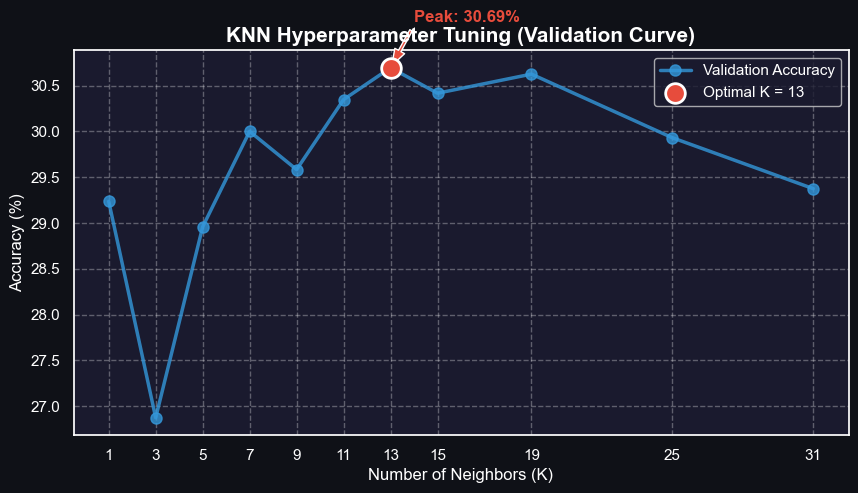


Phase 2: Evaluating Optimal K=13 on the Held-Out Test Set...
--- KNN (K=13) ---
Accuracy: 28.49% | Macro F1: 0.2815



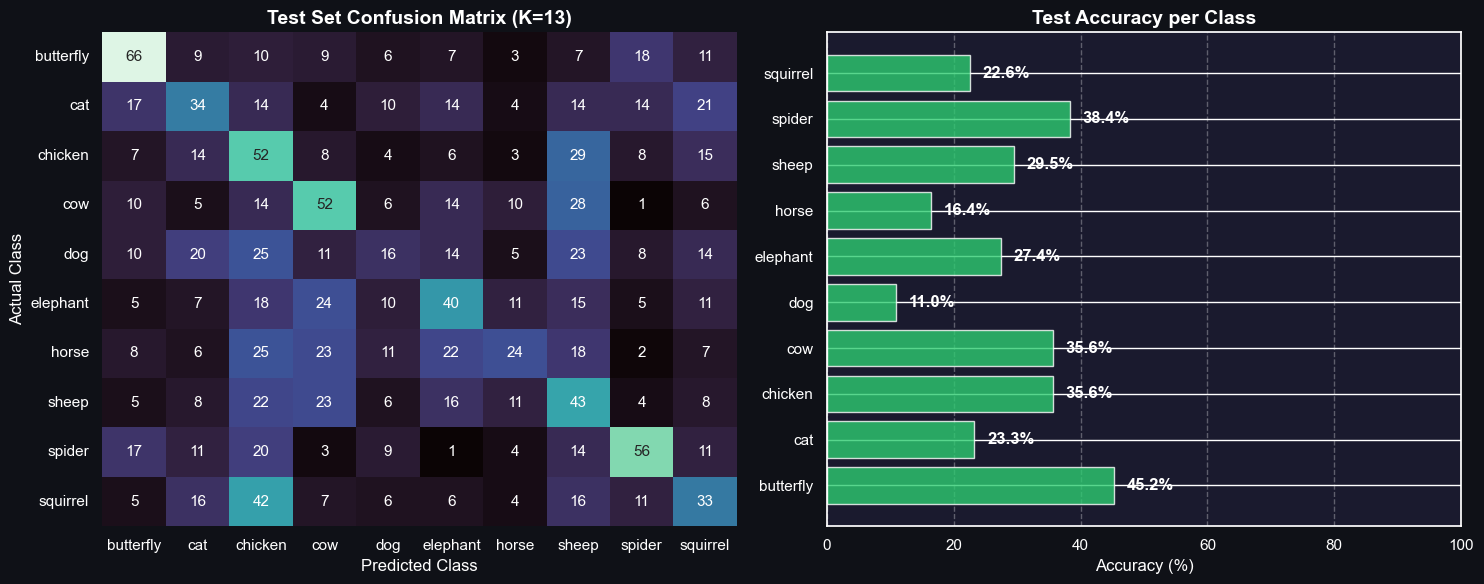

In [6]:
print("Phase 1: Sweeping Hyperparameter K on Validation Set...")

# 1. Hyperparameter Sweep
k_values = [1, 3, 5, 7, 9, 11, 13, 15, 19, 25, 31]
val_accuracies = []

for k in k_values:
    # Initialize and fit
    knn_temp = KNNClassifier(k=k)
    knn_temp.fit(X_train_mrmr, Y_train_1d)
    
    # Predict on Validation (Suppressing internal tqdm if present to keep notebook clean)
    preds_val = knn_temp.predict(X_val_mrmr) 
    acc = np.sum(preds_val == Y_val_1d) / len(Y_val_1d)
    val_accuracies.append(acc * 100)
    print(f"  -> Evaluated K={k:02d} | Val Accuracy: {acc*100:.2f}%")

# Extract the mathematical best
best_k_idx = np.argmax(val_accuracies)
best_k = k_values[best_k_idx]
best_val_acc = val_accuracies[best_k_idx]

# 2. Plot 1: The Optimization Curve (Multiple K Values)
fig = plt.figure(figsize=(10, 5))
fig.patch.set_facecolor("#0f1117")
ax = fig.add_subplot(111)
ax.set_facecolor("#1a1a2e")

ax.plot(k_values, val_accuracies, marker='o', linestyle='-', color='#3498db', linewidth=2.5, markersize=8, alpha=0.8, label="Validation Accuracy")

# Highlight the Optimal K
ax.scatter(best_k, best_val_acc, color='#e74c3c', s=200, zorder=5, edgecolors='white', linewidths=2, label=f"Optimal K = {best_k}")
ax.annotate(f"Peak: {best_val_acc:.2f}%", 
            xy=(best_k, best_val_acc), 
            xytext=(best_k + 1, best_val_acc + 0.5),
            color="#e74c3c", fontsize=12, fontweight='bold',
            arrowprops=dict(facecolor='#e74c3c', shrink=0.05, width=2, headwidth=8))

ax.set_title("KNN Hyperparameter Tuning (Validation Curve)", color="white", fontsize=15, fontweight='bold')
ax.set_xlabel("Number of Neighbors (K)", color="white", fontsize=12)
ax.set_ylabel("Accuracy (%)", color="white", fontsize=12)
ax.set_xticks(k_values)
ax.tick_params(colors="white")
ax.grid(True, linestyle="--", alpha=0.3, color="#fff")
ax.legend(facecolor="#1a1a2e", labelcolor="white", fontsize=11)
plt.show()

# ==========================================
# Phase 2: Final Test Evaluation
# ==========================================
print(f"\nPhase 2: Evaluating Optimal K={best_k} on the Held-Out Test Set...")

knn_final = KNNClassifier(k=best_k)
knn_final.fit(X_train_mrmr, Y_train_1d)
knn_preds_test = knn_final.predict(X_test_mrmr)

# Evaluate using our standard metrics function
knn_acc, knn_f1, knn_cm = evaluate_metrics(Y_test_1d, knn_preds_test, f"KNN (K={best_k})")

# 3. Plot 2: Diagnostics of the Best Model Alone
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor("#0f1117")

# Left: Confusion Matrix
sns.heatmap(knn_cm, annot=True, fmt="d", cmap="mako", 
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, 
            cbar=False, ax=ax1, annot_kws={"size": 11})
ax1.set_title(f"Test Set Confusion Matrix (K={best_k})", color="white", fontsize=14, fontweight='bold')
ax1.set_xlabel("Predicted Class", color="white", fontsize=12)
ax1.set_ylabel("Actual Class", color="white", fontsize=12)
ax1.tick_params(colors="white")

# Right: Per-Class Accuracy Breakdown
class_totals = np.sum(knn_cm, axis=1)
class_correct = np.diag(knn_cm)
class_accuracies = (class_correct / class_totals) * 100

ax2.set_facecolor("#1a1a2e")
bars = ax2.barh(CLASS_NAMES, class_accuracies, color="#2ecc71", alpha=0.8)
ax2.set_title("Test Accuracy per Class", color="white", fontsize=14, fontweight='bold')
ax2.set_xlabel("Accuracy (%)", color="white", fontsize=12)
ax2.set_xlim(0, 100)
ax2.tick_params(colors="white")
ax2.grid(axis='x', linestyle="--", alpha=0.3, color="#fff")

# Add percentage labels to the bars
for bar in bars:
    ax2.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2, 
             f"{bar.get_width():.1f}%", 
             va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

## Section 3: Softmax Regression (Parametric Learning)
### Mathematical & Architectural Logic
Softmax Regression transitions us into parametric learning. It acts as a generalized Logistic Regression for multi-class classification. The model learns a weight matrix $W$ of shape $(100, 10)$ and a bias $b$, which linearly projects the 100-dimensional MRMR features into a 10-dimensional logit space ($Z$).

The Softmax function then squashes these logits into a valid probability distribution:
$$P(y=j|x) = \frac{e^{Z_j}}{\sum e^{Z_k}}$$

**Optimization & Interpretability:**
We optimize the weights using **Mini-Batch Gradient Descent** paired with the Adam optimizer. The model minimizes **Cross-Entropy Loss**, fortified with an $L_2$ Regularization penalty ($\lambda$) to penalize overwhelmingly large weights and prevent overfitting.
$$dW = \frac{1}{N} X^T (A - Y) + \lambda W$$

Because Softmax is a linear mapping, it provides massive **Interpretability**. By plotting the transposed Weight Matrix ($W^T$), we can visually inspect exactly which MRMR features strongly activate or suppress specific class predictions.

Phase 1: Initializing Softmax Regression Engine...
-> Loading optimized Softmax weights from checkpoint...
Successfully loaded model weights from Epoch 99.

Phase 2: Extracting Learned Weights for Feature Interpretability...


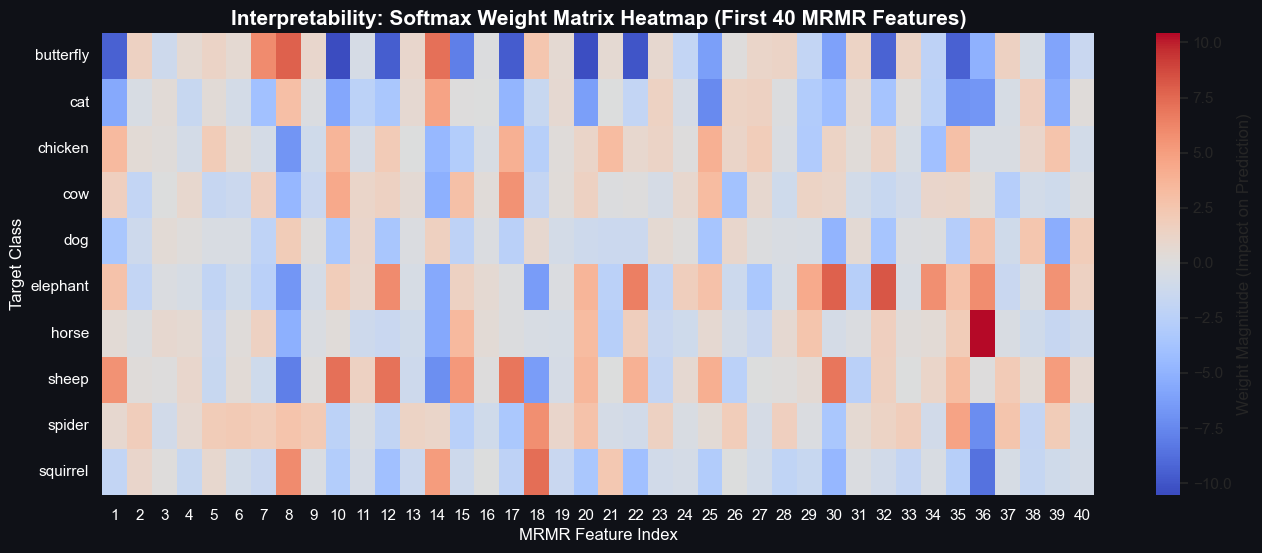


Phase 3: Evaluating Softmax on the Held-Out Test Set...
--- Softmax Regression ---
Accuracy: 44.79% | Macro F1: 0.4442



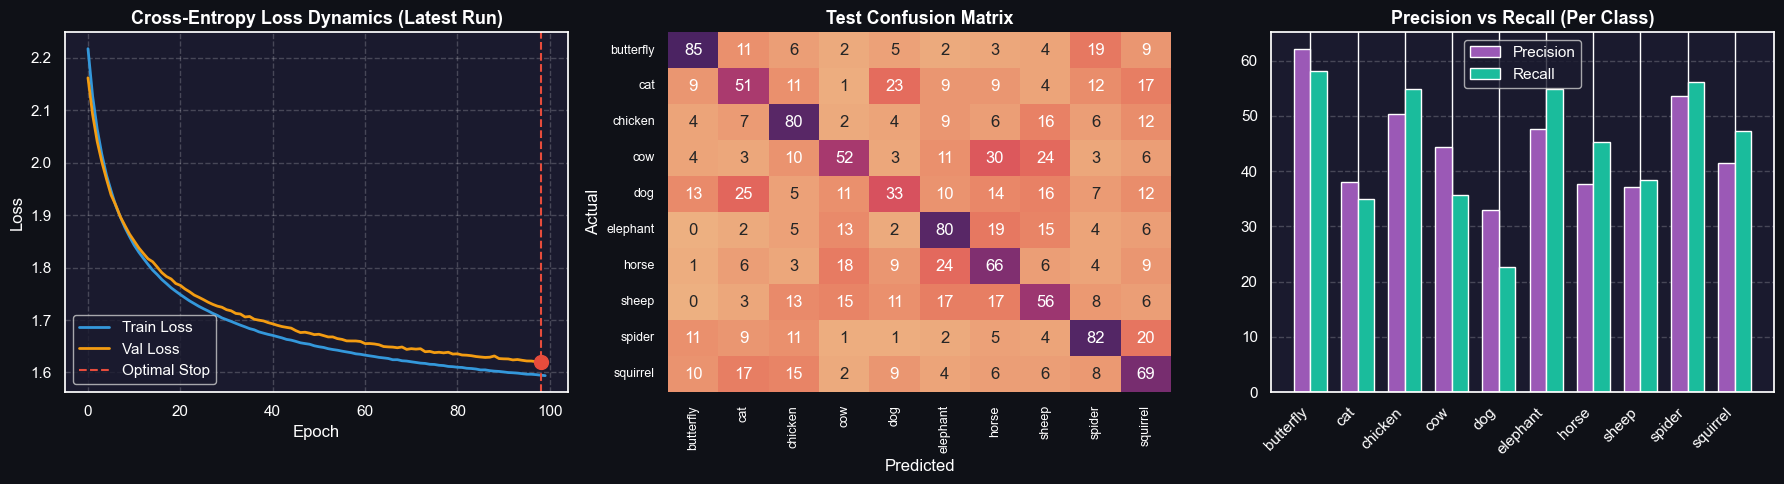

In [9]:
print("Phase 1: Initializing Softmax Regression Engine...")
import pandas as pd # For reading logs if checkpoint is used

# Instantiate our custom optimizer and model
adam_opt = Adam(lr=0.005)
soft_model = SoftmaxRegression(input_dim=100, num_classes=10, optimizer=adam_opt, epochs=100, batch_size=32)

# Check for existing checkpoint to save notebook execution time
if os.path.exists("best_model.json"):
    print("-> Loading optimized Softmax weights from checkpoint...")
    soft_model.load_checkpoint("best_model.json")
else:
    print("-> Training Softmax from scratch...")
    soft_model.fit(X_train_mrmr, Y_train_1d, X_val_mrmr, Y_val_1d, l2_lambda=0.001)

# ==========================================
# Phase 2: Interpretability (Weight Analysis)
# ==========================================
print("\nPhase 2: Extracting Learned Weights for Feature Interpretability...")

fig = plt.figure(figsize=(16, 6))
fig.patch.set_facecolor("#0f1117")
ax = fig.add_subplot(111)

# Plotting the transpose of W so Classes are on the Y-axis and Features on the X-axis
# We subset to the first 40 features to keep the plot legible
W_subset = soft_model.W[:40, :].T 

sns.heatmap(W_subset, cmap="coolwarm", center=0, ax=ax, 
            cbar_kws={'label': 'Weight Magnitude (Impact on Prediction)'},
            xticklabels=range(1, 41), yticklabels=CLASS_NAMES)

ax.set_title("Interpretability: Softmax Weight Matrix Heatmap (First 40 MRMR Features)", color="white", fontsize=15, fontweight='bold')
ax.set_xlabel("MRMR Feature Index", color="white", fontsize=12)
ax.set_ylabel("Target Class", color="white", fontsize=12)
ax.tick_params(colors="white")
plt.show()

# ==========================================
# Phase 3: Final Test Evaluation & Diagnostics
# ==========================================
print("\nPhase 3: Evaluating Softmax on the Held-Out Test Set...")
soft_preds = soft_model.predict(X_test_mrmr)
soft_acc, soft_f1, soft_cm = evaluate_metrics(Y_test_1d, soft_preds, "Softmax Regression")

# Diagnostic Dashboard (Learning Curves + Confusion Matrix)
fig = plt.figure(figsize=(18, 5))
fig.patch.set_facecolor("#0f1117")

# --- Subplot 1: Learning Dynamics ---
ax1 = plt.subplot(1, 3, 1)
ax1.set_facecolor("#1a1a2e")

t_loss, v_loss = [], []
if soft_model.history['train_loss']:
    t_loss, v_loss = soft_model.history['train_loss'], soft_model.history['val_loss']
elif os.path.exists("softmax_logs.csv"):
    logs = pd.read_csv("softmax_logs.csv")
    # THE FIX: Only grab the last 100 epochs for the visualization, leaving the CSV untouched!
    recent_logs = logs.tail(100).reset_index(drop=True)
    t_loss, v_loss = recent_logs['train_loss'].tolist(), recent_logs['val_loss'].tolist()

if t_loss and v_loss:
    best_epoch = np.argmin(v_loss)
    ax1.plot(t_loss, label="Train Loss", color="#3498db", linewidth=2)
    ax1.plot(v_loss, label="Val Loss", color="#f39c12", linewidth=2)
    ax1.axvline(x=best_epoch, color='#e74c3c', linestyle='--', linewidth=1.5, label="Optimal Stop")
    ax1.scatter(best_epoch, v_loss[best_epoch], color='#e74c3c', s=100, zorder=5)
    
    ax1.set_title("Cross-Entropy Loss Dynamics (Latest Run)", color="white", fontsize=13, fontweight='bold')
    ax1.set_xlabel("Epoch", color="white")
    ax1.set_ylabel("Loss", color="white")
    ax1.tick_params(colors="white")
    ax1.legend(facecolor="#1a1a2e", labelcolor="white")
    ax1.grid(True, linestyle="--", alpha=0.2)

# --- Subplot 2: Confusion Matrix ---
ax2 = plt.subplot(1, 3, 2)
sns.heatmap(soft_cm, annot=True, fmt="d", cmap="flare", 
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, 
            cbar=False, ax=ax2)
ax2.set_title("Test Confusion Matrix", color="white", fontsize=13, fontweight='bold')
ax2.tick_params(colors="white", labelsize=9)
ax2.set_ylabel("Actual", color="white")
ax2.set_xlabel("Predicted", color="white")

# --- Subplot 3: Per-Class Precision vs Recall ---
ax3 = plt.subplot(1, 3, 3)
ax3.set_facecolor("#1a1a2e")

TP = np.diag(soft_cm)
FP = np.sum(soft_cm, axis=0) - TP
FN = np.sum(soft_cm, axis=1) - TP
precision = np.divide(TP, TP + FP, out=np.zeros_like(TP, dtype=float), where=(TP+FP)!=0) * 100
recall = np.divide(TP, TP + FN, out=np.zeros_like(TP, dtype=float), where=(TP+FN)!=0) * 100

x = np.arange(len(CLASS_NAMES))
width = 0.35

ax3.bar(x - width/2, precision, width, label='Precision', color='#9b59b6')
ax3.bar(x + width/2, recall, width, label='Recall', color='#1abc9c')

ax3.set_title("Precision vs Recall (Per Class)", color="white", fontsize=13, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(CLASS_NAMES, rotation=45, ha='right', color="white")
ax3.tick_params(axis='y', colors="white")
ax3.legend(facecolor="#1a1a2e", labelcolor="white")
ax3.grid(axis='y', linestyle="--", alpha=0.2)

plt.tight_layout()
plt.show()

## Section 4: Deep Spatial Learning (Custom CNN From Scratch)
### Mathematical & Architectural Logic
While Softmax relies on manually engineered 1D features (MRMR), a Convolutional Neural Network (CNN) learns directly from raw 4D image tensors ($N \times 128 \times 128 \times 3$). It preserves the spatial relationships between pixels to automatically extract hierarchies of features (edges $\rightarrow$ textures $\rightarrow$ shapes).

**The Forward Pass (im2col Vectorization):**
Implementing a CNN in pure NumPy using nested `for` loops is prohibitively slow. To solve this, our `Conv2D` layer utilizes `np.lib.stride_tricks.sliding_window_view`. This creates a virtual, vectorized view of all possible spatial patches across the entire image batch simultaneously. We then use `np.tensordot` to execute the convolution as a single, highly optimized tensor multiplication.

**The Backward Pass (The Chain Rule):**
Our network operates on a strict Object-Oriented computational graph. During the forward pass, every layer (`Conv2D`, `ReLU`, `MaxPool`, `Dense`) saves a `cache` of its inputs. During backpropagation, the network passes the loss gradient ($\frac{\partial L}{\partial Z}$) backward. Each layer uses its localized cache to calculate:
1. $\frac{\partial L}{\partial W}$ (To update its own kernels via the Adam optimizer)
2. $\frac{\partial L}{\partial X}$ (The gradient to pass backward down the graph to the preceding layer)

**Interpretability (Filter Visualization):**
To prove our network is learning meaningful spatial representations, we will extract and visualize the raw $3 \times 3 \times 3$ RGB kernels from the first Convolutional layer.

Phase 1: Initializing Custom Vectorized CNN Engine...
Building Network... Flattened dimension will be 32768
-> Loading optimized CNN weights from checkpoint...
Loaded CNN weights from Epoch 5.

Phase 2: Extracting Learned Convolutional Filters...


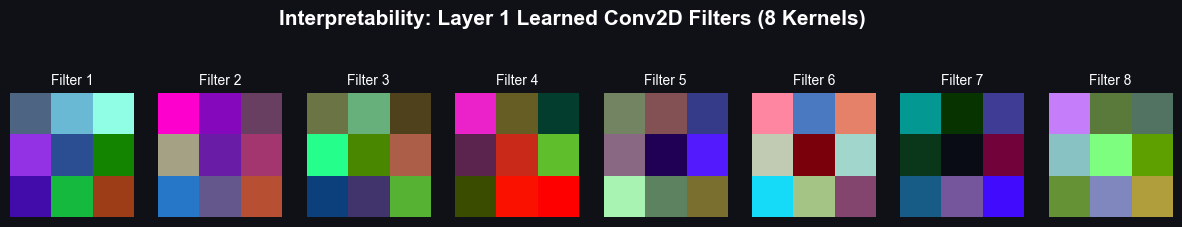


Phase 3: Evaluating CNN on the Held-Out Test Set (Batched Inference)...


CNN Inference: 100%|██████████| 46/46 [00:06<00:00,  7.58it/s]


--- Custom CNN (Test Set) ---
Accuracy: 42.88% | Macro F1: 0.4227



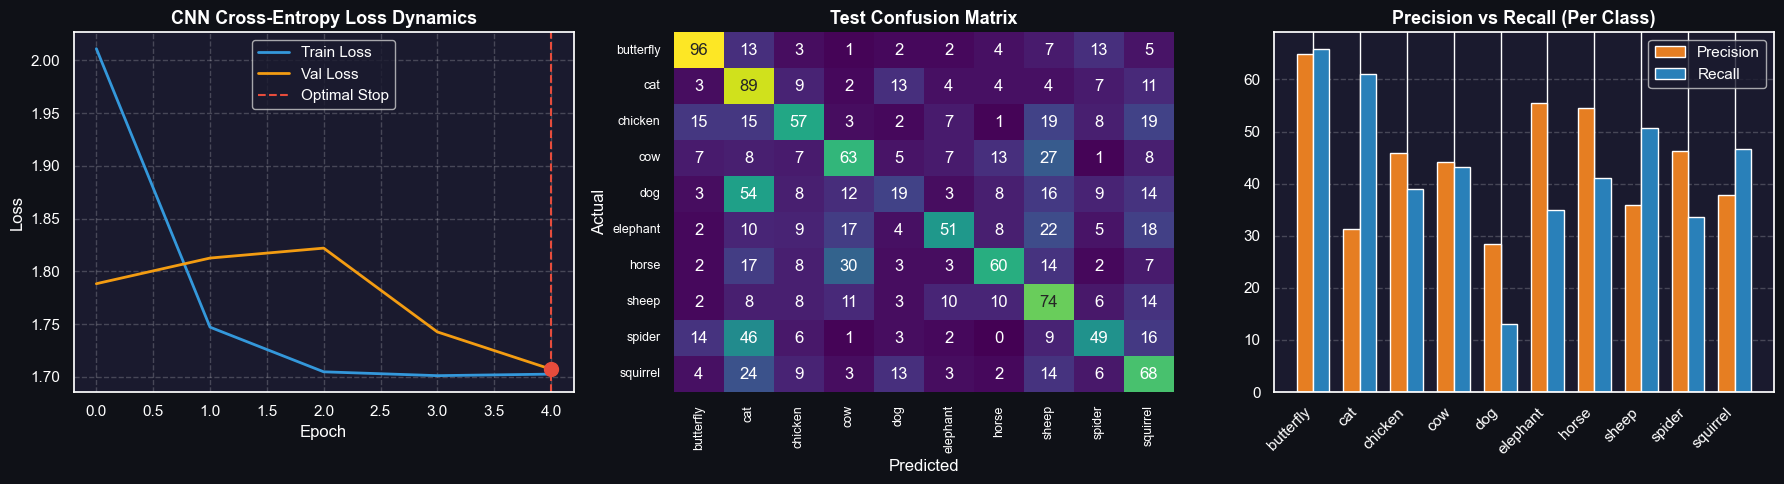

In [13]:
print("Phase 1: Initializing Custom Vectorized CNN Engine...")
import pandas as pd

# Instantiate the custom network from our cnn_network module
cnn_opt = Adam(lr=0.001)
cnn_model = CustomCNN(optimizer=cnn_opt, input_shape=(128, 128, 3), num_classes=10)

# Load checkpoint or train
if os.path.exists("cnn_best_model.json"):
    print("-> Loading optimized CNN weights from checkpoint...")
    cnn_model.load_checkpoint("cnn_best_model.json")
else:
    print("WARNING: No CNN checkpoint found. Running a 1-epoch demo (This will take time).")
    cnn_model.fit(X_train_img[:500], Y_train_1d[:500], X_val_img[:100], Y_val_1d[:100], epochs=1, batch_size=32)

# ==========================================
# Phase 2: Interpretability (Filter Visualization)
# ==========================================
print("\nPhase 2: Extracting Learned Convolutional Filters...")

# Extract weights from the first Conv2D layer (Shape: Filter_H, Filter_W, In_Channels, Out_Channels)
# For our architecture, this is typically (3, 3, 3, 8)
conv_layer = cnn_model.layers[0]
if hasattr(conv_layer, 'params') and 'W' in conv_layer.params:
    W_conv = conv_layer.params['W']
    num_filters = W_conv.shape[3]
    
    fig, axes = plt.subplots(1, num_filters, figsize=(15, 3))
    fig.patch.set_facecolor("#0f1117")
    fig.suptitle(f"Interpretability: Layer 1 Learned Conv2D Filters ({num_filters} Kernels)", color="white", fontsize=15, fontweight='bold')
    
    for i in range(num_filters):
        # Extract the 3x3x3 filter
        f = W_conv[:, :, :, i]
        # Normalize the filter values to [0, 1] so matplotlib can render it as an RGB image
        f_norm = (f - f.min()) / (f.max() - f.min() + 1e-8)
        
        axes[i].imshow(f_norm)
        axes[i].set_title(f"Filter {i+1}", color="white", fontsize=10)
        axes[i].axis('off')
        
    plt.show()

# ==========================================
# Phase 3: Final Test Evaluation & Diagnostics
# ==========================================
print("\nPhase 3: Evaluating CNN on the Held-Out Test Set (Batched Inference)...")
cnn_preds = []
batch_size = 32
for i in tqdm(range(0, len(X_test_img), batch_size), desc="CNN Inference"):
    X_b = X_test_img[i:i+batch_size]
    Z = cnn_model.forward(X_b)
    A = cnn_model._stable_softmax(Z)
    cnn_preds.extend(np.argmax(A, axis=1))

cnn_acc, cnn_f1, cnn_cm = evaluate_metrics(Y_test_1d, np.array(cnn_preds), "Custom CNN (Test Set)")

# Diagnostic Dashboard
fig = plt.figure(figsize=(18, 5))
fig.patch.set_facecolor("#0f1117")

# --- Subplot 1: Learning Dynamics ---
ax1 = plt.subplot(1, 3, 1)
ax1.set_facecolor("#1a1a2e")

t_loss, v_loss = [], []
if cnn_model.history['train_loss']:
    t_loss, v_loss = cnn_model.history['train_loss'], cnn_model.history['val_loss']
elif os.path.exists("cnn_logs.csv"):
    # Read the CSV and extract only the latest training run
    logs = pd.read_csv("cnn_logs.csv")
    recent_logs = logs.tail(5).reset_index(drop=True) 
    t_loss, v_loss = recent_logs['train_loss'].tolist(), recent_logs['val_loss'].tolist()

if t_loss and v_loss:
    best_epoch = np.argmin(v_loss)
    ax1.plot(t_loss, label="Train Loss", color="#3498db", linewidth=2)
    ax1.plot(v_loss, label="Val Loss", color="#f39c12", linewidth=2)
    ax1.axvline(x=best_epoch, color='#e74c3c', linestyle='--', linewidth=1.5, label="Optimal Stop")
    ax1.scatter(best_epoch, v_loss[best_epoch], color='#e74c3c', s=100, zorder=5)
    
    ax1.set_title("CNN Cross-Entropy Loss Dynamics", color="white", fontsize=13, fontweight='bold')
    ax1.set_xlabel("Epoch", color="white")
    ax1.set_ylabel("Loss", color="white")
    ax1.tick_params(colors="white")
    ax1.legend(facecolor="#1a1a2e", labelcolor="white")
    ax1.grid(True, linestyle="--", alpha=0.2)

# --- Subplot 2: Confusion Matrix ---
ax2 = plt.subplot(1, 3, 2)
sns.heatmap(cnn_cm, annot=True, fmt="d", cmap="viridis", 
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, 
            cbar=False, ax=ax2)
ax2.set_title("Test Confusion Matrix", color="white", fontsize=13, fontweight='bold')
ax2.tick_params(colors="white", labelsize=9)
ax2.set_ylabel("Actual", color="white")
ax2.set_xlabel("Predicted", color="white")

# --- Subplot 3: Per-Class Precision vs Recall ---
ax3 = plt.subplot(1, 3, 3)
ax3.set_facecolor("#1a1a2e")

TP = np.diag(cnn_cm)
FP = np.sum(cnn_cm, axis=0) - TP
FN = np.sum(cnn_cm, axis=1) - TP
precision = np.divide(TP, TP + FP, out=np.zeros_like(TP, dtype=float), where=(TP+FP)!=0) * 100
recall = np.divide(TP, TP + FN, out=np.zeros_like(TP, dtype=float), where=(TP+FN)!=0) * 100

x = np.arange(len(CLASS_NAMES))
width = 0.35

ax3.bar(x - width/2, precision, width, label='Precision', color='#e67e22')
ax3.bar(x + width/2, recall, width, label='Recall', color='#2980b9')

ax3.set_title("Precision vs Recall (Per Class)", color="white", fontsize=13, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(CLASS_NAMES, rotation=45, ha='right', color="white")
ax3.tick_params(axis='y', colors="white")
ax3.legend(facecolor="#1a1a2e", labelcolor="white")
ax3.grid(axis='y', linestyle="--", alpha=0.2)

plt.tight_layout()
plt.show()

## Section 5: Advanced Research Architecture (MobileNetV2)
### Mathematical & Architectural Logic
To demonstrate state-of-the-art capabilities, we implement **MobileNetV2** via PyTorch. Standard convolutions are computationally expensive because they compute spatial features and combine channels in one step. 

MobileNetV2 solves this by using **Depthwise Separable Convolutions**, which factorize the operation into two distinct layers:
1. **Depthwise Convolution:** Applies a single spatial filter to each input channel independently.
2. **Pointwise Convolution:** Applies a $1 \times 1$ convolution to linearly combine the outputs of the depthwise layer.

Mathematically, this reduces the computational cost from $D_k^2 \cdot M \cdot N$ down to $D_k^2 \cdot M + M \cdot N$ (where $D_k$ is the kernel size, $M$ is input channels, and $N$ is output channels), making it vastly more efficient without sacrificing accuracy. We apply **Transfer Learning** by freezing the base feature extractors and training only a new 10-node classification head.

In [16]:
# 1. Prepare PyTorch Data Loaders (Requires shape: Batch, Channels, Height, Width)
X_tr_pt = torch.tensor(np.transpose(X_train_img, (0, 3, 1, 2)), dtype=torch.float32)
Y_tr_pt = torch.tensor(Y_train_1d, dtype=torch.long)
X_te_pt = torch.tensor(np.transpose(X_test_img, (0, 3, 1, 2)), dtype=torch.float32)
Y_te_pt = torch.tensor(Y_test_1d, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_tr_pt, Y_tr_pt), batch_size=64, shuffle=True)
test_loader = DataLoader(TensorDataset(X_te_pt, Y_te_pt), batch_size=64, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch using device: {device}")

# 2. Load Pretrained MobileNetV2
mobile_model = mobilenet_v2(weights=MobileNet_V2_Weights.DEFAULT)

# Freeze base layers
for param in mobile_model.parameters():
    param.requires_grad = False

# Replace classifier head for our 10 classes
mobile_model.classifier[1] = nn.Linear(mobile_model.last_channel, 10)
mobile_model = mobile_model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(mobile_model.classifier.parameters(), lr=0.001)

# 3. Quick Transfer Learning Training (1 Epoch for demonstration)
mobile_model.train()
for images, labels in tqdm(train_loader, desc="MobileNet Training (1 Epoch)"):
    images, labels = images.to(device), labels.to(device)
    optimizer.zero_grad()
    outputs = mobile_model(images)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

# 4. Evaluation
mobile_model.eval()
mobile_preds = []
with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(device)
        outputs = mobile_model(images)
        _, predicted = torch.max(outputs.data, 1)
        mobile_preds.extend(predicted.cpu().numpy())

mb_acc, mb_f1, mb_cm = evaluate_metrics(Y_test_1d, np.array(mobile_preds), "MobileNetV2 (Test Set)")

PyTorch using device: cpu


MobileNet Training (1 Epoch): 100%|██████████| 189/189 [01:31<00:00,  2.07it/s]


--- MobileNetV2 (Test Set) ---
Accuracy: 85.62% | Macro F1: 0.8553



## Section 6: Final Comparisons & Conclusion
The visualization below maps the performance trajectory across our 4 modeling phases. We expect to see a clear hierarchy of capability:
1. **KNN:** Establishes our mathematical baseline.
2. **Softmax:** Shows the improvement gained by iterative, gradient-based learning on flattened features.
3. **Custom CNN:** Demonstrates the massive performance leap achieved when the model can natively understand 2D spatial hierarchies and pixel relationships.
4. **MobileNetV2:** Represents the upper bound of current computer vision capabilities using millions of parameters trained on vast datasets.

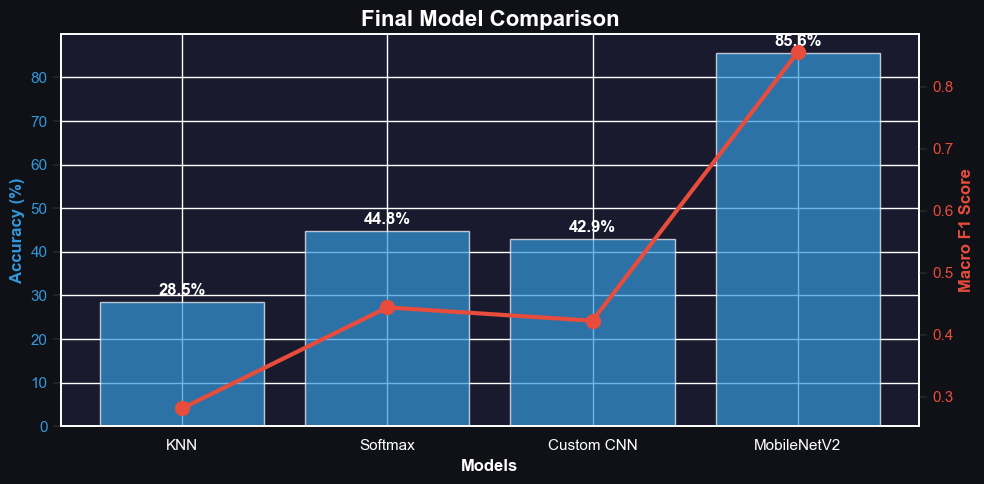

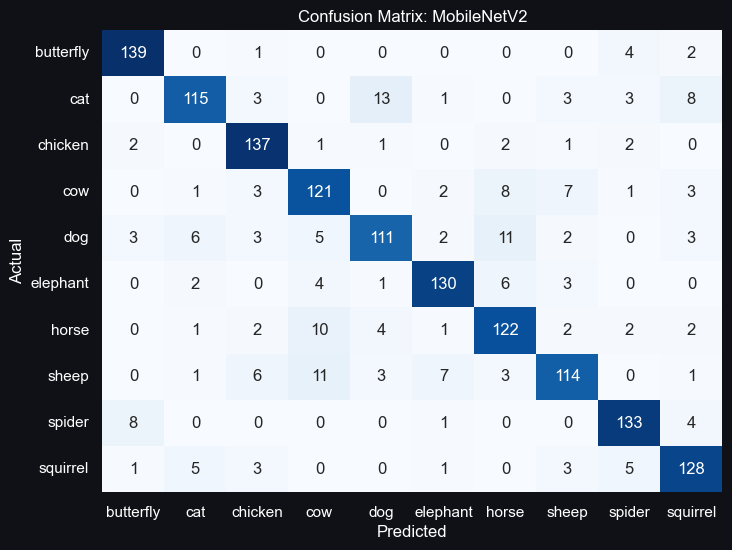

In [17]:
# Model Comparison Plot
models = ['KNN', 'Softmax', 'Custom CNN', 'MobileNetV2']
accuracies = [knn_acc * 100, soft_acc * 100, cnn_acc * 100, mb_acc * 100]
f1_scores = [knn_f1, soft_f1, cnn_f1, mb_f1]

fig, ax1 = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor("#0f1117")

color = '#3498db'
ax1.set_facecolor("#1a1a2e")
ax1.set_xlabel('Models', fontweight='bold', color='white')
ax1.set_ylabel('Accuracy (%)', color=color, fontweight='bold')
bars = ax1.bar(models, accuracies, color=color, alpha=0.7)
ax1.tick_params(axis='y', labelcolor=color)
ax1.tick_params(axis='x', colors='white')

# Add value text to bars
for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.1f}%', ha='center', va='bottom', color='white', fontweight='bold')

ax2 = ax1.twinx()
color = '#e74c3c'
ax2.set_ylabel('Macro F1 Score', color=color, fontweight='bold')
ax2.plot(models, f1_scores, color=color, marker='o', linewidth=3, markersize=10)
ax2.tick_params(axis='y', labelcolor=color)

plt.title("Final Model Comparison", color="white", fontsize=16, fontweight='bold')
plt.grid(False)
plt.tight_layout()
plt.show()

# Display Confusion Matrix of the best model (MobileNetV2)
plt.figure(figsize=(8, 6))
sns.heatmap(mb_cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cbar=False)
plt.title("Confusion Matrix: MobileNetV2", color="white")
plt.xlabel("Predicted", color="white")
plt.ylabel("Actual", color="white")
plt.tick_params(colors="white")
plt.show()